In [1]:
from scipy import stats
import numpy as np
import os
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import wilcoxon 
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator
import statsmodels.formula.api as smf
from statannotations.Annotator import Annotator

In [2]:
plt.close("all")

import sys
print(sys.version)

print("Seaborn", sns.__version__)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Seaborn 0.13.2


## Load images and Filter

In [270]:
NR0_4_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Results_complete_no_erosion_NR0_1nM.csv")
NR7_4_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Results_complete_no_erosion_NR7_1nM.csv")
NR_4_raw = pd.concat([NR0_4_raw,NR7_4_raw])
ctrl_4_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Results_complete_no_erosion_ctrl.csv")

NR_5_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_5\Results_complete_no_erosion_NR.csv")
ctrl_5_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Results_complete_no_erosion_ctrl.csv")

NR0_6_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_6\Results_complete_no_erosion_NR0_1nM.csv")
NR7_6_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_6\Results_complete_no_erosion_NR7_1nM.csv")
NR_6_raw = pd.concat ([NR0_6_raw, NR7_6_raw])
ctrl_6_raw = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_6\Results_complete_no_erosion_ctrl.csv")


In [942]:
NR_4_raw["biorep"] = 1
NR_5_raw["biorep"] = 2
NR_6_raw["biorep"] = 3

NR_4_raw.reset_index(drop=True, inplace=True)
NR_4_raw["cell_uid"] = np.arange(len(NR_4_raw))

NR_5_raw.reset_index(drop=True, inplace=True)
NR_5_raw["cell_uid"] = np.arange(len(NR_5_raw))

NR_6_raw.reset_index(drop=True, inplace=True)
NR_6_raw["cell_uid"] = np.arange(len(NR_6_raw))

df_raw=pd.concat([NR_4_raw, NR_5_raw, NR_6_raw])
print(len(df_raw))

60121


In [272]:
df_raw.set_index("cycle", drop = False, inplace=True)

df_raw["sample"] = ""
df_raw["Benzonase"] = ""
df_raw["Techn_repl"] = ""

df_raw.loc[df_raw.index.str.contains("NR0"), "sample"] = "NR0"
df_raw.loc[df_raw.index.str.contains("NR7"), "sample"] = "NR7"
df_raw.loc[df_raw.index.str.contains("ctrl"), "sample"] = "ctrl"

df_raw.loc[df_raw.index.str.contains("plus"), "Benzonase"] = "plus"
df_raw.loc[df_raw.index.str.contains("minus"), "Benzonase"] = "minus"
df_raw.loc[df_raw.index.str.contains("ctrl"), "Benzonase"] = "minus"

df_raw.loc[df_raw.index.str.contains("tr1"), "Techn_repl"] = 1
df_raw.loc[df_raw.index.str.contains("tr2"), "Techn_repl"] = 2
df_raw.loc[df_raw.index.str.contains("tr3"), "Techn_repl"] = 3

df_raw["group"] = (df_raw["sample"] + "_" + df_raw["Benzonase"])

df_raw.rename(columns={"NR vesicle count": "NR_vesicle_count"}, inplace= True)

df_raw["unique_img_ID"] = (
    df_raw["group"].astype(str)
    + "_"
    + df_raw["frame"].astype(str)
    + "_"
    + df_raw["Techn_repl"].astype(str)
    + "_"
    + df_raw["cycle"].astype(str)
    + "_"
    + df_raw["biorep"].astype(str)
)

df_raw["very_unique_cell_ID"] = (
    df_raw["biorep"].astype(str)
    + "_"
    + df_raw["cell_uid"].astype(str)
)

df_raw["Unique_Tech_Rep"] = df_raw["biorep"].astype(str) + "_Tech" + df_raw["Techn_repl"].astype(str)

#df_raw.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics_raw.csv")
df_raw.head()

,sample,cycle,frame,Cell ID,Endo total area,Lyso total area,NR total signal,NR in Endo mean int median nr unsegm,NR in Lyso mean int median nr unsegm,NR in Endo total int median nr unsegm,...,List for coloc per vesicle endo,List for coloc per vesicle lyso,biorep,cell_uid,Benzonase,Techn_repl,group,unique_img_ID,very_unique_cell_ID,Unique_Tech_Rep
cycle,,,,,,,,,,,,,,,,,,,,,
NR0_1nM_minus_benzo_tr1_Cycle,NR0,NR0_1nM_minus_benzo_tr1_Cycle,NR0_1nM_minus_benzo_tr1_A01_G001_0001.frames,1,513,202,179523,10.666667,9.333333,121.0,...,[],[],1,0,minus,1,NR0_minus,NR0_minus_NR0_1nM_minus_benzo_tr1_A01_G001_000...,1_0,1_Tech1
NR0_1nM_minus_benzo_tr1_Cycle,NR0,NR0_1nM_minus_benzo_tr1_Cycle,NR0_1nM_minus_benzo_tr1_A01_G001_0001.frames,2,453,623,163021,12.250000,7.800000,112.5,...,[],[],1,1,minus,1,NR0_minus,NR0_minus_NR0_1nM_minus_benzo_tr1_A01_G001_000...,1_1,1_Tech1
NR0_1nM_minus_benzo_tr1_Cycle,NR0,NR0_1nM_minus_benzo_tr1_Cycle,NR0_1nM_minus_benzo_tr1_A01_G001_0001.frames,3,265,263,60545,12.766667,8.433761,132.0,...,[],[],1,2,minus,1,NR0_minus,NR0_minus_NR0_1nM_minus_benzo_tr1_A01_G001_000...,1_2,1_Tech1
NR0_1nM_minus_benzo_tr1_Cycle,NR0,NR0_1nM_minus_benzo_tr1_Cycle,NR0_1nM_minus_benzo_tr1_A01_G001_0001.frames,4,426,418,133414,32.043056,8.311111,552.5,...,"[{""nr_label"": 2, ""endo_label"": 96, ""overlap_pi...","[{""nr_label"": 2, ""lyso_label"": 185, ""overlap_p...",1,3,minus,1,NR0_minus,NR0_minus_NR0_1nM_minus_benzo_tr1_A01_G001_000...,1_3,1_Tech1
NR0_1nM_minus_benzo_tr1_Cycle,NR0,NR0_1nM_minus_benzo_tr1_Cycle,NR0_1nM_minus_benzo_tr1_A01_G001_0001.frames,5,763,453,146947,8.250000,8.166667,95.0,...,[],[],1,4,minus,1,NR0_minus,NR0_minus_NR0_1nM_minus_benzo_tr1_A01_G001_000...,1_4,1_Tech1


In [174]:
min_vesicle = 0
NR_4 = NR_4_raw[(NR_4_raw["NR vesicle count"] > min_vesicle) ]
ctrl_4 = ctrl_4_raw[(ctrl_4_raw["NR vesicle count"] > min_vesicle)]

NR_5 = NR_5_raw[(NR_5_raw["NR vesicle count"] > min_vesicle) ]
ctrl_5 = ctrl_5_raw[(ctrl_5_raw["NR vesicle count"] > min_vesicle) ]

NR_6 = NR_6_raw[(NR_6_raw["NR vesicle count"] > min_vesicle) ]
ctrl_6 = ctrl_6_raw[(ctrl_6_raw["NR vesicle count"] > min_vesicle) ]

In [480]:
exp_4 = pd.concat([NR_4, ctrl_4])
exp_5 = pd.concat([NR_5, ctrl_5])
exp_6 = pd.concat([NR_6, ctrl_6])

exp_6["cycle"] = exp_6["cycle"].replace("NR7_1nM_minus_benzo_Cycle", "NR7_1nM_minus_benzo_tr3_Cycle")
print(exp_6.columns.tolist())

['sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR mean signal per cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR vesicle count', 'NR mean vesicle size', 'NR median vesicle size', 'NR total vesicle intensity median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR fraction of segmented pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap endo intensity frac', 'NR intensity overlap lyso', 'Overlap lyso intensity frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep']


### Make summary and plot again for more than 0 NR vesicles

In [773]:
df_raw["has_nr_vesicle"]= ""

df_raw["has_nr_vesicle"] = (df_raw["NR_vesicle_count"] > 0).astype(int)

In [774]:
print(df_raw.columns.tolist())

['sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR mean signal per cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR_vesicle_count', 'NR mean vesicle size', 'NR median vesicle size', 'NR total vesicle intensity median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR fraction of segmented pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap endo intensity frac', 'NR intensity overlap lyso', 'Overlap lyso intensity frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'cell_uid', 'Benzonase', 'Te

In [775]:
table_summary = df_raw.groupby("group")["has_nr_vesicle"].agg(
    included="sum",
    count ="size",
    fraction ="mean"
)


table_summary = table_summary.reindex(index=['NR0_plus',  'NR7_plus', 'NR0_minus', 'NR7_minus'])


table_summary = table_summary.T

print(table_summary)

latex_table = table_summary.to_latex(
    index=True,  # To not include the DataFrame index as a column in the table
    caption="Summary of analyzed cells dataset 2",  # The caption to appear above the table in the LaTeX document
    label="tab:summary_exp.4-6",  # A label used for referencing the table within the LaTeX document
    position="h",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lccc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  
)

print(latex_table)

group         NR0_plus      NR7_plus     NR0_minus     NR7_minus
included   4491.000000   6095.000000   5281.000000   7958.000000
count     14598.000000  14568.000000  14822.000000  16133.000000
fraction      0.307645      0.418383      0.356295      0.493275
\begin{table}[h]
\caption{Summary of analyzed cells dataset 2}
\label{tab:summary_exp.4-6}
\begin{tabular}{lccc}
\toprule
group & NR0_plus & NR7_plus & NR0_minus & NR7_minus \\
\midrule
included & 4491.00 & 6095.00 & 5281.00 & 7958.00 \\
count & 14598.00 & 14568.00 & 14822.00 & 16133.00 \\
fraction & 0.31 & 0.42 & 0.36 & 0.49 \\
\bottomrule
\end{tabular}
\end{table}



In [776]:
per_frame = (df_raw
    .groupby(["group", "biorep", "Unique_Tech_Rep", "unique_img_ID"], as_index=False)
    .agg(fraction=("has_nr_vesicle", "mean")))

per_tr = (per_frame
    .groupby(["group", "biorep", "Unique_Tech_Rep"], as_index=False)
    .agg(fraction=("fraction", "mean")))

per_biorep = (per_tr
    .groupby(["group", "biorep"], as_index=False)
    .agg(fraction=("fraction", "mean")))

In [777]:
significances = pd.read_csv("D:/Uni/Master/Masterarbeit/Image Analysis/Statistics/p_values_holm_raw_df.csv")
print(significances)

             contrast  estimate        SE   df  asymp.LCL  asymp.UCL  \
0  NR0: plus vs minus -0.049155  0.040258  inf  -0.149709   0.051398   
1  NR7: plus vs minus -0.103679  0.044895  inf  -0.215813   0.008456   
2   Minus: NR7 vs NR0  0.203948  0.043380  inf   0.095598   0.312297   
3   Plus:  NR7 vs NR0  0.149425  0.042559  inf   0.043124   0.255725   

    z.ratio   p.value  
0 -1.221003  0.222085  
1 -2.309364  0.041847  
2  4.701456  0.000010  
3  3.510979  0.001339  


In [778]:
# STAR ANNOTATIONS

pairs = [
    ("NR0_minus", "NR0_plus"),
    ("NR7_minus", "NR7_plus"),
    ("NR0_minus", "NR7_minus"),
    ("NR0_plus", "NR7_plus")
]

# Step 2: Map the R contrast names to your pairs
# R named them: "NR0: plus vs minus", "NR7: plus vs minus", etc.
contrast_mapping = {
    ("NR0_minus", "NR0_plus"): "NR0: plus vs minus",
    ("NR7_minus", "NR7_plus"): "NR7: plus vs minus",
    ("NR0_minus", "NR7_minus"): "Minus: NR7 vs NR0",
    ("NR0_plus", "NR7_plus"): "Plus:  NR7 vs NR0"
}

# Step 3: Extract the exact p-values in the order of your pairs
p_values_fraction = []
for pair in pairs:
    r_contrast_name = contrast_mapping[pair]
    # Extract the p-value for this specific contrast
    p_val = significances[significances["contrast"] == r_contrast_name]["p.value"].values[0]
    p_values_fraction.append(p_val)

print(p_values_fraction)

[np.float64(0.222084996492351), np.float64(0.0418467653625601), np.float64(1.0332505854384e-05), np.float64(0.001339377825673)]


C:\Users\jelka\AppData\Local\Temp\ipykernel_9104\1916577132.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jelka\AppData\Local\Temp\ipykernel_9104\1916577132.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["NR0","NR7","NR0","NR7"], fontsize = tick_font)


NR0_minus vs. NR7_minus: Custom statistical test, P_val:1.033e-05
NR0_plus vs. NR7_plus: Custom statistical test, P_val:1.339e-03
NR0_plus vs. NR0_minus: Custom statistical test, P_val:2.221e-01
NR7_plus vs. NR7_minus: Custom statistical test, P_val:4.185e-02


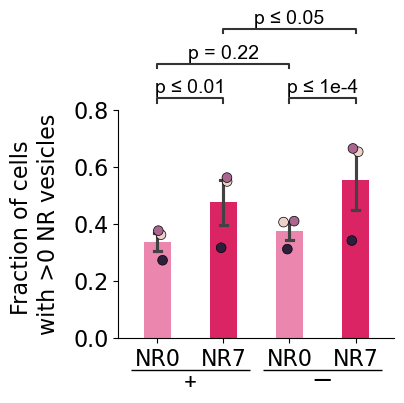

In [779]:
palette_barplt = {
    "NR0_plus": "#FC76AB",
    "NR7_plus": "#FA055B",
    "NR0_minus": "#FC76AB",
    "NR7_minus": "#FA055B"
}

ylabel = {"fraction": "Fraction of cells \nwith >0 NR vesicles"}
col = "fraction"

boxplot_font= 16
tick_font =16
text_offset = -0.225
y_pos = -0.14

ymin= 0
ymax= 0.6

fig, ax = plt.subplots(figsize=(4, 4))

"""sns.boxplot(
    data=per_frame,
    x="group",
    y=col,
    order=order,
    palette=palette,
    showfliers=False,
    width=0.4,
    ax=ax,
    #showmeans=True,  # <--- Blendet den Mittelwert ein!
    #meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6}
)"""

sns.barplot( 
    data= per_biorep,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    palette = palette_barplt,
    legend = False,
    errorbar="se", 
    width = 0.4,
    capsize = 0.1,
    fill = True
)

"""
sns.stripplot( 
    data= df_statistics_per_frame_mean,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    hue = "biorep",
    #palette = palette_dts,
    s=3,
    legend = False,
    #edgecolor="black", #Black border around squares
    #linewidth=0.5,
    alpha=0.4, #0.6
    clip_on = False
)"""

sns.stripplot( 
    data= per_biorep,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    hue = "biorep",
    #palette = palette_dts,
    s=7, #7
    legend = False,
    edgecolor="black", #Black border around squares
    linewidth=0.5,
    alpha=1, #0.8
    #color = "black",
    clip_on = False
) 

sns.despine(ax=ax, top=True, right=True, trim=False)  # ← trim=False


# -------------------------------
# GROUP LABELS PRO SUBPLOT
# -------------------------------
xticks = ax.get_xticks()

# Mitte der ersten 2 und letzten 2 Boxen
x_1nM = (xticks[0] + xticks[1]) / 2
x_10nM = (xticks[2] + xticks[3]) / 2

ax.text(
    x_1nM, text_offset,
    "+",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize= boxplot_font,
    color = "black"
)

ax.text(
    x_10nM, - 0.16,
    "_",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize= 20,
    color = "black"
)


y = y_pos  # unter der Achse (in axes coords)

# 1 nM (linke 2 Boxen)
ax.hlines(
    y=y, xmin=-0.4, xmax=1.4,
    transform=ax.get_xaxis_transform(),
    color="black",
    linewidth=1,
    clip_on=False
)

# 10 nM (rechte 2 Boxen)
ax.hlines(
    y=y, xmin=1.6, xmax=3.4,
    transform=ax.get_xaxis_transform(),
    color="black",
    linewidth=1,
    clip_on=False
)


ax.set_title(None)
ax.set_xlabel("")
ax.tick_params(axis='both', labelsize= tick_font)
ax.set_ylabel(ylabel[col], fontsize = boxplot_font, labelpad = 10)
#ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(["NR0","NR7","NR0","NR7"], fontsize = tick_font)
ax.spines['top'].set_color("lightgray")
ax.spines['right'].set_color("lightgray")
#ax.set_box_aspect(1)
#ax.set_anchor('E')
#ax.margins(y=0.01)
yticks = ax.get_yticks()
ax.set_ylim(ymin, ymax)
ax.set_ylim(yticks[0], yticks[-1])
#ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))

#-------------------------------
# P-VALUES
#----------------------------------
# Initialize the annotator
annot = Annotator(ax, pairs, data = per_biorep, x="group", y= col, order = order)
annot.configure(text_format='simple', loc='outside', fontsize = 14)

(annot
 .set_pvalues(pvalues=p_values_fraction)
 .annotate())

for text in ax.texts:
    text.set_fontname("Arial")


plt.subplots_adjust(
    left=0.3,
    right=0.99,
    top=0.72,
    bottom=0.15)




plt.savefig(f"D:/Uni/Master/Masterarbeit/Image Analysis/Figures/Subfigures/Barplt_{col}_boxfont_{boxplot_font}_tick_font{tick_font}_exp_4-6_no_erosion_min_ves_3_p_values", dpi=600, transparent = True)
plt.show()

## Rearrange Dataframes

In [176]:
experiments = [exp_4, exp_5, exp_6]

for e in experiments:
    e.set_index("cycle", drop = False, inplace=True)

    e["sample"] = ""
    e["Benzonase"] = ""
    e["Techn_repl"] = ""

    e.loc[e.index.str.contains("NR0"), "sample"] = "NR0"
    e.loc[e.index.str.contains("NR7"), "sample"] = "NR7"
    e.loc[e.index.str.contains("ctrl"), "sample"] = "ctrl"

    e.loc[e.index.str.contains("plus"), "Benzonase"] = "plus"
    e.loc[e.index.str.contains("minus"), "Benzonase"] = "minus"
    e.loc[e.index.str.contains("ctrl"), "Benzonase"] = "minus"

    e.loc[e.index.str.contains("tr1"), "Techn_repl"] = 1
    e.loc[e.index.str.contains("tr2"), "Techn_repl"] = 2
    e.loc[e.index.str.contains("tr3"), "Techn_repl"] = 3

    e["group"] = (e["sample"] + " " + e["Benzonase"])

In [177]:
for e in experiments:
    e.reset_index(drop=True, inplace=True)
    e["cell_uid"] = np.arange(len(e))
    print(e.index.is_unique)

True
True
True


## Extract Data

In [178]:
overlap_df_endo = []
overlap_df_lyso = []
for e in experiments:
    all_overlaps_endo = []
    
    for _, row in e.iterrows():
        overlaps = json.loads(row["List for coloc per vesicle endo"])
    
        for overlap in overlaps:
            overlap["Cell ID"] = row["Cell ID"]
            overlap["frame"] = row["frame"]
            overlap["cycle"] = row["cycle"]
            overlap["group"] =row["group"]
            overlap["Techn_repl"] =row["Techn_repl"]
            overlap["cell_uid"] =row["cell_uid"]
    
            all_overlaps_endo.append(overlap)
    
    overlap_df_endo.append(pd.DataFrame(all_overlaps_endo))
    
    
    all_overlaps_lyso = []
    
    for _, row in e.iterrows():
        overlaps = json.loads(row["List for coloc per vesicle lyso"])
    
        for overlap in overlaps:
            overlap["Cell ID"] = row["Cell ID"]
            overlap["frame"] = row["frame"]
            overlap["cycle"] = row["cycle"]
            overlap["group"] =row["group"]
            overlap["Techn_repl"] =row["Techn_repl"]
            overlap["cell_uid"] =row["cell_uid"]
    
            all_overlaps_lyso.append(overlap)
    
    overlap_df_lyso.append(pd.DataFrame(all_overlaps_lyso))

In [179]:
min_overlap=0.5

overlap_endo_filtered_nr = []
overlap_endo_filtered_endo = []
overlap_lyso_filtered_nr = []
overlap_lyso_filtered_lyso = []

for df in overlap_df_endo:
    
    overlap_endo_filtered_nr.append(df [df["overlap_frac_of_nr_in_endo"] > min_overlap])
    overlap_endo_filtered_endo.append(df [df["overlap_frac_of_endo_has_nr"] > min_overlap])

for df in overlap_df_lyso:
    
    overlap_lyso_filtered_nr.append(df [df["overlap_frac_of_nr_in_lyso"] > min_overlap])
    overlap_lyso_filtered_lyso.append(df[df["overlap_frac_of_lyso_has_nr"] > min_overlap])

In [180]:
# POSITIVE NR VESICLES FOR ENDO AND LYSOSOME
positive_per_cell_endo = []

for df in overlap_endo_filtered_nr:
    positive_per_cell_endo.append(
    df
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_nr_vesicles_endo")
    )

positive_per_cell_lyso = []

for df in overlap_lyso_filtered_nr:
    positive_per_cell_lyso.append(
    df
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_nr_vesicles_lyso")
)

# POSITIVE ENDO AND LYSO VESICLES FOR NRS

positive_per_cell_endo_has_nr = []

for df in overlap_endo_filtered_endo:
    positive_per_cell_endo_has_nr.append(
    df
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_endo_vesicles")
)

positive_per_cell_lyso_has_nr = []

for df in overlap_lyso_filtered_lyso:
    positive_per_cell_lyso_has_nr.append(
    df
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_lyso_vesicles")
)

In [181]:
df_complete = experiments.copy()

additional_dfs = [
    positive_per_cell_endo,
    positive_per_cell_lyso,
    positive_per_cell_endo_has_nr,
    positive_per_cell_lyso_has_nr
]

for additions in additional_dfs:
    for i, (e, df) in enumerate(zip(df_complete, additions)):
        df_complete[i] = e.merge(
            df,
            on="cell_uid",
            how="left"
        )

In [182]:
for e in df_complete:
    e["positive_nr_vesicles_endo"] = (
        e["positive_nr_vesicles_endo"]
    .fillna(0)
    .astype(int)
    )

    e["positive_nr_vesicles_lyso"] = (
    e["positive_nr_vesicles_lyso"]
    .fillna(0)
    .astype(int)
    )

    e["positive_endo_vesicles"] = (
    e["positive_endo_vesicles"]
    .fillna(0)
    .astype(int)
    )

    e["positive_lyso_vesicles"] = (
    e["positive_lyso_vesicles"]
    .fillna(0)
    .astype(int)
    )

    e = e.drop("List for coloc per vesicle endo", axis=1)
    e = e.drop("List for coloc per vesicle lyso", axis=1)

exp_4_complete, exp_5_complete, exp_6_complete = df_complete
print(exp_4_complete.columns.tolist())

['sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR mean signal per cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR vesicle count', 'NR mean vesicle size', 'NR median vesicle size', 'NR total vesicle intensity median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR fraction of segmented pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap endo intensity frac', 'NR intensity overlap lyso', 'Overlap lyso intensity frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', 'Techn_repl', '

In [183]:
for e in df_complete:
    e["fraction_nr_in_endo"] = (
        e["positive_nr_vesicles_endo"] / e["NR vesicle count"]
    )
    
    e["fraction_nr_in_lyso"] = (
        e["positive_nr_vesicles_lyso"] / e["NR vesicle count"]
    )
    
    e["fraction_endo_with_nr"] = (
        e["positive_endo_vesicles"] / e["Endo vesicle count"]
    )
    e["fraction_lyso_with_nr"] = (
        e["positive_lyso_vesicles"] / e["Lyso vesicle count"]
    )

exp_4_complete, exp_5_complete, exp_6_complete = df_complete

#exp_4_complete.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Data_extracted.csv")
#exp_5_complete.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_5\Data_extracted.csv")
#exp_6_complete.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_6\Data_extracted.csv")

In [184]:
overlap_df_endo_4, overlap_df_endo_5, overlap_df_endo_6 = overlap_df_endo

overlap_df_endo_4["biorep"] = 1
overlap_df_endo_5["biorep"] = 2
overlap_df_endo_6["biorep"] = 3

overlap_df_endo = [overlap_df_endo_4, overlap_df_endo_5, overlap_df_endo_6]

overlap_df_lyso_4, overlap_df_lyso_5, overlap_df_lyso_6 = overlap_df_lyso

In [185]:
nr_overlap_count = (
    overlap_df_endo_4
    .groupby(["group","cell_uid","endo_label"])["nr_label"]
    .nunique()
)

print(nr_overlap_count.value_counts())

nr_endo_count = (
    overlap_df_endo_4
    .groupby(["group", "cell_uid","nr_label"])["endo_label"]
    .nunique()
)

print(nr_endo_count.value_counts())

nr_label
1    6808
2     449
3      41
4       8
6       1
Name: count, dtype: int64
endo_label
1    5680
2     963
3      73
4       8
5       2
Name: count, dtype: int64


In [186]:
#### ALL REPLICATES TOGETHER 
# NR7 minus
overlap_df_nr_in_endo_NR7_minus = []
for e in overlap_df_endo:   
    overlap_df_nr_in_endo_NR7_minus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_nr_in_endo"
    ])

overlap_df_nr_in_endo_full_NR7_minus = pd.concat(overlap_df_nr_in_endo_NR7_minus, ignore_index = True)

overlap_df_endo_has_nr_NR7_minus = []
for e in overlap_df_endo:
    overlap_df_endo_has_nr_NR7_minus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_endo_has_nr"
    ])

overlap_df_endo_has_nr_full_NR7_minus = pd.concat(overlap_df_endo_has_nr_NR7_minus, ignore_index = True)

###### NR7 plus
overlap_df_nr_in_endo_NR7_plus = []
for e in overlap_df_endo:   
    overlap_df_nr_in_endo_NR7_plus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_nr_in_endo"
    ])

overlap_df_nr_in_endo_full_NR7_plus = pd.concat(overlap_df_nr_in_endo_NR7_plus, ignore_index = True)

overlap_df_endo_has_nr_NR7_plus = []
for e in overlap_df_endo:
    overlap_df_endo_has_nr_NR7_plus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_endo_has_nr"
    ])

overlap_df_endo_has_nr_full_NR7_plus = pd.concat(overlap_df_endo_has_nr_NR7_plus, ignore_index = True)

## NR0 minus

overlap_df_nr_in_endo_NR0_minus = []
for e in overlap_df_endo:   
    overlap_df_nr_in_endo_NR0_minus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_nr_in_endo"
    ])

overlap_df_nr_in_endo_full_NR0_minus = pd.concat(overlap_df_nr_in_endo_NR0_minus, ignore_index = True)

overlap_df_endo_has_nr_NR0_minus = []
for e in overlap_df_endo:
    overlap_df_endo_has_nr_NR0_minus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_endo_has_nr"
    ])

overlap_df_endo_has_nr_full_NR0_minus = pd.concat(overlap_df_endo_has_nr_NR0_minus, ignore_index = True)

# NR0 PLUS
overlap_df_nr_in_endo_NR7_plus = []
for e in overlap_df_endo:   
    overlap_df_nr_in_endo_NR7_plus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_nr_in_endo"
    ])

overlap_df_nr_in_endo_full_NR7_plus = pd.concat(overlap_df_nr_in_endo_NR7_plus, ignore_index = True)

overlap_df_endo_has_nr_NR0_plus = []
for e in overlap_df_endo:
    overlap_df_endo_has_nr_NR0_plus.append(e.loc[
        e["group"] == "NR7 minus",
        "overlap_frac_of_endo_has_nr"
    ])

overlap_df_endo_has_nr_full_NR0_plus = pd.concat(overlap_df_endo_has_nr_NR0_plus, ignore_index = True)

display(overlap_df_nr_in_endo_full_NR7_minus)

0        0.222222
1        0.200000
2        0.074074
3        0.500000
4        1.000000
           ...   
16373    0.444444
16374    0.151515
16375    1.000000
16376    0.142857
16377    0.666667
Name: overlap_frac_of_nr_in_endo, Length: 16378, dtype: float64

count: 58322
positive: 1350
ratio: 0.023147354343129523
count: 10151
positive: 2777
ratio: 0.27356910649197125


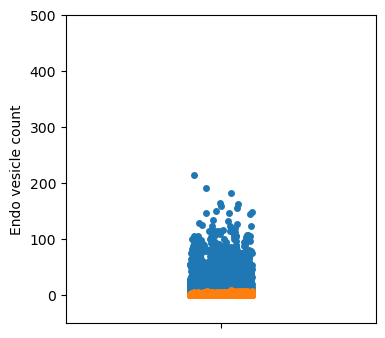

In [187]:
count = exp_4_complete.loc[
    exp_4_complete["group"] == "NR7 minus",
    "Endo vesicle count"
    ]


positive = exp_4_complete.loc[
    exp_4_complete["group"] == "NR7 minus",
    "positive_endo_vesicles"
    ]

print("count:", count.sum())
print("positive:", positive.sum())
print("ratio:", positive.sum()/count.sum())

fig, axes = plt.subplots(figsize = (4,4))
sns.stripplot(
    data = count)

sns.stripplot(data = positive)
axes.set_ylim(-50,500)

count = exp_4_complete.loc[
    exp_4_complete["group"] == "NR7 minus",
    "NR vesicle count"
    ]


positive = exp_4_complete.loc[
    exp_4_complete["group"] == "NR7 minus",
    "positive_nr_vesicles_endo"
    ]

print("count:", count.sum())
print("positive:", positive.sum())
print("ratio:", positive.sum()/count.sum())

#fig, axes = plt.subplots(figsize = (4,4))
#sns.stripplot(
#    data = count)

#sns.stripplot(data = positive)
#axes.set_ylim(-50,500)

## Statistics

### Load images

In [2]:
exp_4_complete = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_4\Data_extracted.csv", index_col=0)
exp_5_complete = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_5\Data_extracted.csv", index_col=0)
exp_6_complete = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Exp_6\Data_extracted.csv", index_col=0)


In [3]:
print(exp_4_complete.columns.tolist())

['sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR mean signal per cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR vesicle count', 'NR mean vesicle size', 'NR median vesicle size', 'NR total vesicle intensity median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR fraction of segmented pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap endo intensity frac', 'NR intensity overlap lyso', 'Overlap lyso intensity frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', 'Techn_repl', '

In [4]:
exp_4_complete["biorep"] = 1
exp_5_complete["biorep"] = 2
exp_6_complete["biorep"] = 3

In [5]:
df_statistics = pd.concat([exp_4_complete, exp_5_complete, exp_6_complete])
#df_statistics.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\complete_df_exp_4-6.csv")
print(df_statistics.columns.tolist())

df_statistics["group"] = df_statistics["group"].replace("NR7 plus", "NR7_plus")
df_statistics["group"] = df_statistics["group"].replace("NR0 plus", "NR0_plus")
df_statistics["group"] = df_statistics["group"].replace("NR7 minus", "NR7_minus")
df_statistics["group"] = df_statistics["group"].replace("NR0 minus", "NR0_minus")
df_statistics = df_statistics[df_statistics['group']!='ctrl minus']
print(len(df_statistics))

['sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR mean signal per cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR vesicle count', 'NR mean vesicle size', 'NR median vesicle size', 'NR total vesicle intensity median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR fraction of segmented pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap endo intensity frac', 'NR intensity overlap lyso', 'Overlap lyso intensity frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', 'Techn_repl', '

In [45]:
print("Fraction NR in Lyso N/A",(df_statistics["fraction_nr_in_lyso"].isna().mean() * 100))
print("Fraction NR in Endo N/A",(df_statistics["fraction_nr_in_endo"].isna().mean() * 100))
print("Fraction Lyso int frac NR N/A",(df_statistics["Overlap lyso intensity frac"].isna().mean() * 100))
print("Fraction Endo int frac NR N/A",(df_statistics["Overlap endo intensity frac"].isna().mean() * 100))
print("Fraction endo with NR N/A",(df_statistics["fraction_endo_with_nr"].isna().mean() * 100))
print("Fraction Lyso with NR N/A",(df_statistics["fraction_lyso_with_nr"].isna().mean() * 100))

Fraction NR in Lyso N/A 0.0
Fraction NR in Endo N/A 0.0
Fraction Lyso int frac NR N/A 8.381951731374606
Fraction Endo int frac NR N/A 0.2938090241343127
Fraction endo with NR N/A 0.2938090241343127
Fraction Lyso with NR N/A 8.381951731374606


### Filter Fractions

NR with Endo

In [6]:
# FRACTION NR WITH ENDO
df_statistics_filtered_nr_in_endo = df_statistics[(df_statistics["Overlap endo intensity frac"] > 0)]

df_statistics_filtered_nr_in_endo_per_frame = (
    df_statistics_filtered_nr_in_endo.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          fraction_nr_in_endo =("fraction_nr_in_endo", "median")
      )
)

df_statistics_filtered_nr_in_endo_per_tr = (
    df_statistics_filtered_nr_in_endo_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          fraction_nr_in_endo =("fraction_nr_in_endo", "median")
      )
)

df_statistics_filtered_nr_in_endo_per_biorep = (
    df_statistics_filtered_nr_in_endo_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          fraction_nr_in_endo =("fraction_nr_in_endo", "median")
      )
)

Endo with NR

In [7]:
# FRACTION ENDO WITH NR
df_statistics_filtered_endo_with_nr = df_statistics[(df_statistics["fraction_endo_with_nr"] > 0)]

df_statistics_filtered_endo_with_nr_per_frame = (
    df_statistics_filtered_endo_with_nr.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          fraction_endo_with_nr=("fraction_endo_with_nr", "median")
      )
)

df_statistics_filtered_endo_with_nr_per_tr = (
    df_statistics_filtered_endo_with_nr_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          fraction_endo_with_nr=("fraction_endo_with_nr", "median")
      )
)

df_statistics_filtered_endo_with_nr_per_biorep = (
    df_statistics_filtered_endo_with_nr_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          fraction_endo_with_nr=("fraction_endo_with_nr", "median")
      )
)


no_overlap_fractions = (df_statistics["fraction_endo_with_nr"] == 0).groupby(df_statistics["group"]).mean() * 100
print(no_overlap_fractions)

group
NR0_minus    84.453702
NR0_plus     84.635939
NR7_minus    70.444835
NR7_plus     78.277276
Name: fraction_endo_with_nr, dtype: float64


Lyso with NR

In [8]:
# FRACTION Lyso with NR
df_statistics_filtered_lyso_with_nr = df_statistics[(df_statistics["fraction_lyso_with_nr"] > 0)]

df_statistics_filtered_lyso_with_nr_per_frame = (
    df_statistics_filtered_lyso_with_nr.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median")
      )
)

df_statistics_filtered_lyso_with_nr_per_tr = (
    df_statistics_filtered_lyso_with_nr_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median")
      )
)

df_statistics_filtered_lyso_with_nr_per_biorep = (
    df_statistics_filtered_lyso_with_nr_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median")
      )
)


no_overlap_fractions = (df_statistics["fraction_lyso_with_nr"] == 0).groupby(df_statistics["group"]).mean() * 100
print(no_overlap_fractions)

group
NR0_minus    80.666540
NR0_plus     79.358717
NR7_minus    79.806484
NR7_plus     80.672683
Name: fraction_lyso_with_nr, dtype: float64


Lyso int frac

In [9]:
# FRACTION Lyso with NR
df_statistics_filtered_lyso_int_frac = df_statistics[(df_statistics["Overlap lyso intensity frac"] > 0)]

df_statistics_filtered_lyso_int_frac_per_frame = (
    df_statistics_filtered_lyso_int_frac.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          overlap_lyso_int_frac=("Overlap lyso intensity frac", "median")
      )
)

df_statistics_filtered_lyso_int_frac_per_tr = (
    df_statistics_filtered_lyso_int_frac_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          overlap_lyso_int_frac=("overlap_lyso_int_frac", "median")
      )
)

df_statistics_filtered_lyso_int_frac_per_biorep = (
    df_statistics_filtered_lyso_int_frac_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          overlap_lyso_int_frac=("overlap_lyso_int_frac", "median")
      )
)


no_overlap_fractions = (df_statistics["Overlap lyso intensity frac"] == 0).groupby(df_statistics["group"]).mean() * 100
print(no_overlap_fractions)

group
NR0_minus    64.533232
NR0_plus     62.747718
NR7_minus    62.088464
NR7_plus     63.478261
Name: Overlap lyso intensity frac, dtype: float64


NR in lyso

In [10]:
# FRACTION Lyso with NR
df_statistics_filtered_nr_in_lyso = df_statistics[(df_statistics["fraction_nr_in_lyso"] > 0)]

df_statistics_filtered_nr_in_lyso_per_frame = (
    df_statistics_filtered_lyso_int_frac.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          fraction_nr_in_lyso =("fraction_nr_in_lyso", "median")
      )
)

df_statistics_filtered_nr_in_lyso_per_tr = (
    df_statistics_filtered_nr_in_lyso_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          fraction_nr_in_lyso =("fraction_nr_in_lyso", "median")
      )
)

df_statistics_filtered_nr_in_lyso_per_biorep = (
    df_statistics_filtered_nr_in_lyso_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          fraction_nr_in_lyso =("fraction_nr_in_lyso", "median")
      )
)


no_overlap_fractions = (df_statistics["fraction_nr_in_lyso"] == 0).groupby(df_statistics["group"]).mean() * 100
print(no_overlap_fractions)

group
NR0_minus    85.608786
NR0_plus     82.164329
NR7_minus    85.963810
NR7_plus     85.479902
Name: fraction_nr_in_lyso, dtype: float64


### medians for summary table

In [725]:
NR7_minus_1 = df_statistics[(df_statistics["group"]=="NR7_minus") & (df_statistics["biorep"]== 1) ]
NR7_minus_2 = df_statistics[(df_statistics["group"]=="NR7_minus") & (df_statistics["biorep"]== 2) ]
NR7_minus_3 = df_statistics[(df_statistics["group"]=="NR7_minus") & (df_statistics["biorep"]== 3) ]

NR7_plus_1 = df_statistics[(df_statistics["group"]=="NR7_plus") & (df_statistics["biorep"]== 1) ]
NR7_plus_2 = df_statistics[(df_statistics["group"]=="NR7_plus") & (df_statistics["biorep"]== 2) ]
NR7_plus_3 = df_statistics[(df_statistics["group"]=="NR7_plus") & (df_statistics["biorep"]== 3) ]

NR0_minus_1 = df_statistics[(df_statistics["group"]=="NR0_minus") & (df_statistics["biorep"]== 1)]
NR0_minus_2 = df_statistics[(df_statistics["group"]=="NR0_minus") & (df_statistics["biorep"]== 2)]
NR0_minus_3 = df_statistics[(df_statistics["group"]=="NR0_minus") & (df_statistics["biorep"]== 3)]

NR0_plus_1 = df_statistics[(df_statistics["group"]=="NR0_plus") & (df_statistics["biorep"]== 1)]
NR0_plus_2 = df_statistics[(df_statistics["group"]=="NR0_plus") & (df_statistics["biorep"]== 2)]
NR0_plus_3 = df_statistics[(df_statistics["group"]=="NR0_plus") & (df_statistics["biorep"]== 3)]

df_raw.set_index("cycle", drop = False, inplace=True)
df_raw["group"] = ""
df_raw.loc[df_raw.index.str.contains("NR7_1nM_minus"), "group"] = "NR7 minus"
df_raw.loc[df_raw.index.str.contains("NR7_1nM_plus"), "group"] = "NR7 plus"
df_raw.loc[df_raw.index.str.contains("NR0_1nM_minus"), "group"] = "NR0 minus"
df_raw.loc[df_raw.index.str.contains("NR0_1nM_plus"), "group"] = "NR0 plus"

NR7_minus_raw_1 = df_raw[(df_raw["group"] == "NR7 minus") & (df_raw["biorep"]== 1)]
NR7_minus_raw_2 = df_raw[(df_raw["group"] == "NR7 minus") & (df_raw["biorep"]== 2)]
NR7_minus_raw_3 = df_raw[(df_raw["group"] == "NR7 minus") & (df_raw["biorep"]== 3)]

NR7_plus_raw_1 = df_raw[(df_raw["group"]=="NR7 plus") & (df_raw["biorep"]== 1)]
NR7_plus_raw_2 = df_raw[(df_raw["group"]=="NR7 plus") & (df_raw["biorep"]== 2)]
NR7_plus_raw_3 = df_raw[(df_raw["group"]=="NR7 plus") & (df_raw["biorep"]== 3)]

NR0_minus_raw_1 = df_raw[(df_raw["group"]=="NR0 minus") & (df_raw["biorep"]== 1)]
NR0_minus_raw_2 = df_raw[(df_raw["group"]=="NR0 minus") & (df_raw["biorep"]== 2)]
NR0_minus_raw_3 = df_raw[(df_raw["group"]=="NR0 minus") & (df_raw["biorep"]== 3)]

NR0_plus_raw_1 = df_raw[(df_raw["group"]=="NR0 plus") & (df_raw["biorep"]== 1)]
NR0_plus_raw_2 = df_raw[(df_raw["group"]=="NR0 plus") & (df_raw["biorep"]== 2)]
NR0_plus_raw_3 = df_raw[(df_raw["group"]=="NR0 plus") & (df_raw["biorep"]== 3)]

NR0_minus_raw = [NR0_minus_raw_1, NR0_minus_raw_2, NR0_minus_raw_3]
NR0_minus = [NR0_minus_1, NR0_minus_2, NR0_minus_3]

NR0_plus_raw = [NR0_plus_raw_1, NR0_plus_raw_2, NR0_plus_raw_3]
NR0_plus = [NR0_plus_1, NR0_plus_2, NR0_plus_3]

NR7_minus_raw = [NR7_minus_raw_1, NR7_minus_raw_2, NR7_minus_raw_3]
NR7_minus = [NR7_minus_1, NR7_minus_2, NR7_minus_3]

NR7_plus_raw = [NR7_plus_raw_1, NR7_plus_raw_2, NR7_plus_raw_3]
NR7_plus = [NR7_plus_1, NR7_plus_2, NR7_plus_3]


In [726]:

def statistic_short(df_raw, df):
    return [
        len(df_raw),
        len(df),
        (len(df)/len(df_raw))*100]
           
index= ["Cell count",
        "Cells with >0 NR vesicles",
        "Inculded into analysis [%]"]
        
import pandas as pd

def statistic_summary(raw_list, analysis_list):
    values = []

    for raw, analysis in zip(raw_list, analysis_list):
        values.append(statistic_short(raw, analysis))

    values = pd.DataFrame(values, columns=index)

    summary = values.mean().to_frame("mean")
    summary["std"] = values.std()

    # als String mean ± std
    summary["mean ± std"] = (
        summary["mean"].round(1).astype(str) 
        + " ± " 
        + summary["std"].round(1).astype(str)
    )

    return summary["mean ± std"]

def statistic_range(raw_list, analysis_list):
    values = []

    for raw, analysis in zip(raw_list, analysis_list):
        values.append(statistic_short(raw, analysis))

    values = pd.DataFrame(
        values,
        columns=index
    )

    summary = pd.DataFrame({
        "mean": values.mean(),
        "min": values.min(),
        "max": values.max()
    })

    # als String min (max)
    summary["range"] = (
        summary["mean"].round(0).astype(str)
        + "("
        + summary["min"].round(0).astype(str)
        + " - "
        + summary["max"].round(0).astype(str)
        + ")"
    )

    return summary["range"]


In [727]:
summary_df = pd.DataFrame({
    "NR0 plus": statistic_summary(NR0_plus_raw, NR0_plus),
    "NR7_plus": statistic_summary(NR7_plus_raw, NR7_plus),
    "NR0 minus": statistic_summary(NR0_minus_raw, NR0_minus),
    "NR7_minus": statistic_summary(NR7_minus_raw, NR7_minus)

})

summary_df

summary_2_df = pd.DataFrame({
    "NR0 minus": statistic_range(NR0_minus_raw, NR0_minus),
    "NR7_minus": statistic_range(NR7_minus_raw, NR7_minus),
    "NR0 plus": statistic_range(NR0_plus_raw, NR0_plus),  
    "NR7_plus": statistic_range(NR7_plus_raw, NR7_plus)
})

summary_df

,NR0 plus,NR7_plus,NR0 minus,NR7_minus
Cell count,4866.0 ± 2229.1,4856.0 ± 2702.4,4940.7 ± 2200.6,5377.7 ± 2426.1
Cells with >0 NR vesicles,1497.0 ± 509.7,2031.7 ± 657.9,1760.3 ± 600.8,2652.7 ± 625.3
Inculded into analysis [%],31.9 ± 5.2,46.2 ± 13.2,36.8 ± 5.3,53.7 ± 16.1


In [728]:
latex_table = summary_df.to_latex(
    index=True,  # To not include the DataFrame index as a column in the table
    caption="Summary of analyzed cells dataset 2",  # The caption to appear above the table in the LaTeX document
    label="tab:summary_exp.4-6",  # A label used for referencing the table within the LaTeX document
    position="h",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lccc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.0f}".format  
)

print(latex_table)

\begin{table}[h]
\caption{Summary of analyzed cells dataset 2}
\label{tab:summary_exp.4-6}
\begin{tabular}{lccc}
\toprule
 & NR0 plus & NR7_plus & NR0 minus & NR7_minus \\
\midrule
Cell count & 4866.0 ± 2229.1 & 4856.0 ± 2702.4 & 4940.7 ± 2200.6 & 5377.7 ± 2426.1 \\
Cells with >0 NR vesicles & 1497.0 ± 509.7 & 2031.7 ± 657.9 & 1760.3 ± 600.8 & 2652.7 ± 625.3 \\
Inculded into analysis [%] & 31.9 ± 5.2 & 46.2 ± 13.2 & 36.8 ± 5.3 & 53.7 ± 16.1 \\
\bottomrule
\end{tabular}
\end{table}



In [197]:
summary = {"NR7_minus": [NR7_minus_raw_len, NR7_minus_len, NR7_minus_incl],
           "NR7_plus": [NR7_plus_raw_len, NR7_plus_len, NR7_plus_incl],
           "NR0 minus": [NR0_minus_raw_len, NR0_minus_len, NR0_minus_incl],
           "NR0 plus": [NR0_plus_raw_len, NR0_plus_len, NR0_plus_incl]
}

summary_df = pd.DataFrame(data = summary, index = ["Cell count", "Cells with >0 NR vesicles", "Inlcuded into analysis [%]"])
summary_df = summary_df.round(3)

display(summary_df)

NameError: name 'NR7_minus_raw_len' is not defined

### Nested medians

In [11]:
df_statistics_per_frame = (
    df_statistics.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          NR_vesicle_count=("NR vesicle count", "median"),
          NR_vesicle_int = ('NR total vesicle intensity median', "median"),
          NR_mean_cell_signal = ('NR mean signal per cell', "median"),
          NR_vesicle_fraction = ('NR fraction of segmented pixels', "median"),
          overlap_endo_int_frac =("Overlap endo intensity frac", "median"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "median"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "median"),
          overlap_lyso_int_frac =("Overlap lyso intensity frac", "median"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "median"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median"),
  
        
      )
)

print(df_statistics_per_frame.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['biorep', 'Techn_repl', 'group', 'cycle', 'frame', 'NR_vesicle_count',
       'NR_vesicle_int', 'NR_mean_cell_signal', 'NR_vesicle_fraction',
       'overlap_endo_int_frac', 'fraction_nr_in_endo', 'fraction_endo_with_nr',
       'overlap_lyso_int_frac', 'fraction_nr_in_lyso',
       'fraction_lyso_with_nr'],
      dtype='object')>


In [12]:
df_statistics_per_tr = (
    df_statistics_per_frame.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "median"),
          NR_vesicle_int = ('NR_vesicle_int', "median"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "median"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "median"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "median"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "median"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "median"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "median"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "median"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median"),
  
        
      )
)

In [13]:
df_statistics_median_of_frames = (
    df_statistics_per_frame.groupby( "group", as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "median"),
          NR_vesicle_int = ('NR_vesicle_int', "median"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "median"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "median"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "median"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "median"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "median"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "median"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "median"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median"),
  
        
      )
)

In [14]:
df_statistics_per_biorep = (
    df_statistics_per_tr.groupby(["biorep", "group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "median"),
          NR_vesicle_int = ('NR_vesicle_int', "median"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "median"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "median"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "median"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "median"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "median"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "median"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "median"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median"),
  
        
      )
)

In [15]:
df_statistics_per_condition = (
    df_statistics_per_biorep.groupby(["group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "median"),
          NR_vesicle_int = ('NR_vesicle_int', "median"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "median"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "median"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "median"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "median"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "median"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "median"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "median"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "median"),
  
        
      )
)

### Nested means

In [13]:
print(df_statistics.columns.tolist())

import numpy as np

def gmean(x):
    return np.exp(np.log(x).mean())

['Unnamed: 0', 'sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR_mean_signal_per_cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR_vesicle_count', 'NR mean vesicle size', 'NR median vesicle size', 'NR_total_vesicle_intensity_median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR_fraction_of_segmented_pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap_endo_intensity_frac', 'NR intensity overlap lyso', 'Overlap_lyso_intensity_frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', '

In [14]:
df_statistics_per_frame_mean = (
    df_statistics.groupby(["biorep", "Techn_repl", "group", "cycle", "frame"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "mean"),
          NR_vesicle_int = ('NR_total_vesicle_intensity_median', "mean"),
          NR_mean_cell_signal = ('NR_mean_signal_per_cell', "mean"),
          NR_vesicle_fraction = ('NR_fraction_of_segmented_pixels', "mean"),
          overlap_endo_int_frac =("Overlap_endo_intensity_frac", "mean"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "mean"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "mean"),
          overlap_lyso_int_frac =("Overlap_lyso_intensity_frac", "mean"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "mean"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "mean"),
          nr_size = ("NR median vesicle size", "mean"),
          mean_ves_int = ("NR mean vesicle intensity median", "mean")
  
        
      )
)
#df_statistics_per_frame_mean.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics_gmean_frame.csv")

In [15]:
df_statistics_per_tr_mean = (
    df_statistics_per_frame_mean.groupby(["biorep", "Techn_repl", "group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "mean"),
          NR_vesicle_int = ('NR_vesicle_int', "mean"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "mean"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "mean"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "mean"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "mean"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "mean"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "mean"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "mean"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "mean"),
          nr_size = ("nr_size", "mean"),
          mean_ves_int = ("mean_ves_int", "mean")
        
  
        
      )
)

In [16]:
df_statistics_per_biorep_mean = (
    df_statistics_per_tr_mean.groupby(["biorep", "group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "mean"),
          NR_vesicle_int = ('NR_vesicle_int', "mean"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "mean"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "mean"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "mean"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "mean"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "mean"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "mean"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "mean"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "mean"),
          nr_size = ("nr_size", "mean"),
          mean_ves_int = ("mean_ves_int", "mean")
        
      )
)

#df_statistics_per_biorep_mean.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics_gmean_biorep.csv")

In [17]:
df_statistics_per_condition_mean = (
    df_statistics_per_biorep_mean.groupby(["group"], as_index=False)
      .agg(
          NR_vesicle_count=("NR_vesicle_count", "mean"),
          NR_vesicle_int = ('NR_vesicle_int', "mean"),
          NR_mean_cell_signal = ('NR_mean_cell_signal', "mean"),
          NR_vesicle_fraction = ('NR_vesicle_fraction', "mean"),
          overlap_endo_int_frac =("overlap_endo_int_frac", "mean"),
          fraction_nr_in_endo = ("fraction_nr_in_endo", "mean"),
          fraction_endo_with_nr=("fraction_endo_with_nr", "mean"),
          overlap_lyso_int_frac =("overlap_lyso_int_frac", "mean"),
          fraction_nr_in_lyso = ("fraction_nr_in_lyso", "mean"),
          fraction_lyso_with_nr=("fraction_lyso_with_nr", "mean"),
          nr_size = ("nr_size", "mean"),
          mean_ves_int = ("mean_ves_int", "mean")
        
      )
)
display(df_statistics_per_condition_mean)

,group,NR_vesicle_count,NR_vesicle_int,NR_mean_cell_signal,NR_vesicle_fraction,overlap_endo_int_frac,fraction_nr_in_endo,fraction_endo_with_nr,overlap_lyso_int_frac,fraction_nr_in_lyso,fraction_lyso_with_nr,nr_size,mean_ves_int
0,NR0_minus,3.126626,3151.871731,22.275307,0.071080,0.129932,0.110863,0.008924,0.099032,0.080917,0.024595,11.134106,231.781084
1,NR0_plus,3.295317,2841.361647,21.065295,0.062092,0.134796,0.115700,0.006870,0.122147,0.107282,0.028907,9.858568,225.715321
2,NR7_minus,4.682331,2288.885641,24.429712,0.082491,0.291524,0.259688,0.023521,0.081003,0.063030,0.021193,9.156430,227.291112
3,NR7_plus,4.510018,2040.473118,21.489289,0.065641,0.226975,0.198649,0.011531,0.079782,0.066810,0.016307,8.636973,221.056429


In [831]:
print(df_statistics_per_biorep.columns.tolist())

['biorep', 'group', 'NR_vesicle_count', 'NR_vesicle_int', 'NR_mean_cell_signal', 'NR_vesicle_fraction', 'overlap_endo_int_frac', 'fraction_nr_in_endo', 'fraction_endo_with_nr', 'overlap_lyso_int_frac', 'fraction_nr_in_lyso', 'fraction_lyso_with_nr']


In [832]:
metrics = ['NR_vesicle_count', 
           'NR_vesicle_int', 
           'NR_mean_cell_signal', 
           'NR_vesicle_fraction', 
           'overlap_endo_int_frac', 
           'fraction_nr_in_endo', 
           'fraction_endo_with_nr',  
           'overlap_lyso_int_frac', 
           'fraction_nr_in_lyso', 
           'fraction_lyso_with_nr']


comparisons = [
    ("NR0 minus", "NR0_plus"),
    ("NR7_minus", "NR7_plus"),
    ("NR0_minus", "NR7_minus"),
    ("NR0_plus", "NR7_plus")
]

### Statistics (Mixed effects model)

Unique identifiers for images

In [ ]:
df_statistics.rename(columns={"NR vesicle count": "NR_vesicle_count"}, inplace= True)
df_statistics.rename(columns={"NR total vesicle intensity median": "NR_total_vesicle_intensity_median"}, inplace= True)
df_statistics.rename(columns={"NR mean signal per cell": "NR_mean_signal_per_cell"}, inplace= True)
df_statistics.rename(columns={"NR fraction of segmented pixels": "NR_fraction_of_segmented_pixels"}, inplace= True)
df_statistics.rename(columns={"Overlap endo intensity frac": "Overlap_endo_intensity_frac"}, inplace= True)
df_statistics.rename(columns={"Overlap lyso intensity frac": "Overlap_lyso_intensity_frac"}, inplace= True)


df_statistics["unique_img_ID"] = (
    df_statistics["group"].astype(str)
    + "_"
    + df_statistics["frame"].astype(str)
    + "_"
    + df_statistics["Techn_repl"].astype(str)
    + "_"
    + df_statistics["cycle"].astype(str)
    + "_"
    + df_statistics["biorep"].astype(str)
)

df_statistics["very_unique_cell_ID"] = (
    df_statistics["biorep"].astype(str)
    + "_"
    + df_statistics["cell_uid"].astype(str)
)

df_statistics["Unique_Tech_Rep"] = df_statistics["biorep"].astype(str) + "_Tech" + df_statistics["Techn_repl"].astype(str)

#df_statistics.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics.csv")

print("Groups:", df_statistics["group"].unique())
print("Techreps:", df_statistics["Unique_Tech_Rep"].unique())
print("Cell ID is unique:", df_statistics["very_unique_cell_ID"].is_unique)

In [ ]:
df_statistics.head()

In [ ]:
print(f"Anzahl Zellen: {len(df_statistics)}")
print(f"Anzahl biorep: {df_statistics['biorep'].nunique()}")
print(f"Anzahl Unique_Tech_Rep: {df_statistics['Unique_Tech_Rep'].nunique()}")
print(f"Anzahl unique_img_ID: {df_statistics['unique_img_ID'].nunique()}")
print(f"Anzahl groups: {df_statistics['group'].nunique()}")
print(f"Zellen pro biorep:\n{df_statistics.groupby('biorep').size()}")

In [ ]:
os.environ["R_HOME"]=r"C:\Program Files\R\R-4.6.1"

In [ ]:
print(os.environ.get('R_HOME'))

In [ ]:
print(ro.r(".libPaths()"))

LMM model

In [ ]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "NR_vesicle_count ~ group",  # fester Effekt
    df_statistics,
    groups=df_statistics["biorep"]  # Zufallseffekt: biologische Replikate
)
result_stats = model.fit()
print(result_stats.summary())

In [ ]:
model = smf.mixedlm(
    "NR_vesicle_count ~ group",  # Fester Effekt: Deine 4 Gruppen
    df_statistics,
    groups=df_statistics["biorep"],  # Höchste Cluster-Ebene (Biologische Replikate)
    vc_formula={
        "tech_rep_variance": "0 + C(Unique_Tech_Rep)",  # Ebene: Technisches Replikat
        "image_variance": "0 + C(unique_img_ID)", # Ebene: Einzelnes Bild
    },
)


## Plots

In [833]:
import numpy as np
col = "NR_total_vesicle_intensity_median"
g = df_statistics.groupby("group")[col]
print(g.mean())
print(np.exp(np.log(df_statistics[col]).groupby(df_statistics["group"]).mean()))

group
NR0_minus    3127.561541
NR0_plus     3015.975284
NR7_minus    2332.413295
NR7_plus     2080.021083
Name: NR_total_vesicle_intensity_median, dtype: float64
group
NR0_minus    1818.428514
NR0_plus     1625.752585
NR7_minus    1618.099893
NR7_plus     1518.253622
Name: NR_total_vesicle_intensity_median, dtype: float64


In [3]:
df_statistics = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics.csv")
df_statistics = df_statistics.reset_index(drop=True)
p_values = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\p_values_bonferroni_modified_georges.csv")
p_values_bonferroni = pd.read_csv("D:/Uni/Master/Masterarbeit/Image Analysis/Statistics/p_values_holm_merged_CI.csv")

print(p_values_bonferroni["Metric"].unique())
print(df_statistics["Unique_Tech_Rep"].unique())
print(p_values["Metric"].unique())

['NR_vesicle_count' 'NR_total_vesicle_intensity_median'
 'NR_mean_signal_per_cell' 'NR_fraction_of_segmented_pixels'
 'Overlap_endo_intensity_frac' 'fraction_nr_in_endo'
 'fraction_endo_with_nr' 'Overlap_lyso_intensity_frac'
 'fraction_nr_in_lyso' 'fraction_lyso_with_nr' 'NR.median.vesicle.size']
['1_Tech1' '1_Tech2' '1_Tech3' '2_Tech1' '2_Tech2' '2_Tech3' '3_Tech1'
 '3_Tech2' '3_Tech3']
['NR_vesicle_count' 'NR_total_vesicle_intensity_median'
 'NR_mean_signal_per_cell' 'NR_fraction_of_segmented_pixels'
 'Overlap_endo_intensity_frac' 'fraction_nr_in_endo'
 'fraction_endo_with_nr' 'Overlap_lyso_intensity_frac'
 'fraction_nr_in_lyso' 'fraction_lyso_with_nr']


In [4]:
print(df_statistics.columns.tolist())

['Unnamed: 0', 'sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR_mean_signal_per_cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR_vesicle_count', 'NR mean vesicle size', 'NR median vesicle size', 'NR_total_vesicle_intensity_median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR_fraction_of_segmented_pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap_endo_intensity_frac', 'NR intensity overlap lyso', 'Overlap_lyso_intensity_frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', '

In [5]:
def p_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."

# Beispiel: Erstellt eine neue Spalte mit den Sternen in Python
p_values['stars'] = p_values['p.value'].apply(p_stars)
p_values_bonferroni['stars'] = p_values_bonferroni['p.value'].apply(p_stars)


p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("Overlap_endo_intensity_frac", "overlap_endo_int_frac")
)

p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("Overlap_lyso_intensity_frac", "overlap_lyso_int_frac")
)

p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("NR_fraction_of_segmented_pixels", "NR_vesicle_fraction")
)

p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("NR_total_vesicle_intensity_median", "NR_vesicle_int")
)

p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("NR_mean_signal_per_cell", "NR_mean_cell_signal")
)

p_values_bonferroni["Metric"] = (
    p_values_bonferroni["Metric"]
    .replace("NR.median.vesicle.size", "nr_size")
)

p_values_all = pd.concat([p_values, p_values_bonferroni], axis = 1)

rename = {"NR_mean_cell_signal": "Mean NR intensity per cell",
          "NR_vesicle_int": "NR vesicle intensity",
          "NR_vesicle_count": "NR vesicle count",
          "NR_vesicle_fraction": "NR vesicle fraction",
          "overlap_endo_int_frac": "Fraction of NR signal colocalizing with endosomes",
          "fraction_nr_in_endo": "Fraction of NR vesicles in endosomes",
          "fraction_endo_with_nr": "Fraction of endosomes with NRs",
          "overlap_lyso_int_frac": "Fraction of NR signal colocalizing with lysosomes",
          "fraction_nr_in_lyso": "Fraction of NR vesicles in lysosomes", 
          "fraction_lyso_with_nr": "Fraction of lysosomes with NRs",
          "nr_size": "NR vesicle size",
          "mean_ves_int": "mean vesicle inetnsity"}

rename_2 = {"NR0: plus vs minus": "NR0: (+) vs. (-)",
           "NR7: plus vs minus": "NR7: (+) vs. (-)",
           "Minus: NR7 vs NR0": "(-): NR7 vs NR0",
           "Plus: NR7 vs NR0": "(+): NR7 vs NR0"}
           
           

p_values_bonferroni_copy = p_values_bonferroni.copy()
p_values_bonferroni_copy["Metric"].replace(rename, inplace=True)
p_values_bonferroni_copy["contrast"].replace(rename_2, inplace=True)
p_values_bonferroni_copy = p_values_bonferroni_copy.drop("stars", axis =  1)
p_values_bonferroni_copy = p_values_bonferroni_copy.drop("z.ratio", axis =  1)

C:\Users\jelka\AppData\Local\Temp\ipykernel_10280\4157127286.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_values_bonferroni_copy["Metric"].replace(rename, inplace=True)
C:\Users\jelka\AppData\Local\Temp\ipykernel_10280\4157127286.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [6]:
def fmt_p(p):
    if p < 0.01:
        exp = int(np.floor(np.log10(p)))
        mant = p / 10**exp
        return rf"${mant:.1f} \times 10^{{{exp}}}$"
    return f"{p:.3f}"

tab = p_values_bonferroni_copy.copy()
tab["p.value"] = tab["p.value"].map(fmt_p)

def fmt_sig(x, sig=2):
    if x == 0:
        return "0"
    return f"{x:.{max(0, sig - 1 - int(np.floor(np.log10(abs(x)))))}f}"

for c in ["estimate", "SE", "CI_low", "CI_high"]:
    tab[c] = tab[c].map(fmt_sig)

tab["Metric"] = tab["Metric"].str.replace("_", r"\_", regex=False)

In [7]:
latex_table_p_values = tab.to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    caption="Summary of statistical analyses",  # The caption to appear above the table in the LaTeX document
    label="tab:statistics",  # A label used for referencing the table within the LaTeX document
    position="h",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="XYYYYYYYYY",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,# Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.3f}".format  
)
#print(latex_table_p_values)

In [8]:
print(p_values_bonferroni_copy.dtypes)

Metric       object
Scale        object
contrast     object
estimate    float64
SE          float64
CI_low      float64
CI_high     float64
p.value     float64
dtype: object


In [9]:
print(p_values_bonferroni.columns.tolist())
print(p_values_bonferroni["Metric"].unique())

['Metric', 'Scale', 'contrast', 'estimate', 'SE', 'CI_low', 'CI_high', 'z.ratio', 'p.value', 'stars']
['NR_vesicle_count' 'NR_vesicle_int' 'NR_mean_cell_signal'
 'NR_vesicle_fraction' 'overlap_endo_int_frac' 'fraction_nr_in_endo'
 'fraction_endo_with_nr' 'overlap_lyso_int_frac' 'fraction_nr_in_lyso'
 'fraction_lyso_with_nr' 'nr_size']


In [10]:
order= ["NR0_plus", "NR7_plus", "NR0_minus", "NR7_minus"]

metrics = ['NR_vesicle_count' 'NR_total_vesicle_intensity_median'
 'NR_mean_signal_per_cell' 'NR_fraction_of_segmented_pixels'
 'Overlap_endo_intensity_frac' 'fraction_nr_in_endo'
 'fraction_endo_with_nr' 'Overlap_lyso_intensity_frac'
 'fraction_nr_in_lyso' 'fraction_lyso_with_nr']

ylabel = {"NR_mean_cell_signal": "Mean NR intensity per cell",
          "NR_vesicle_int": "NR vesicle intensity",
          "NR_vesicle_count": "NR vesicle count",
          "NR_vesicle_fraction": "NR vesicle fraction",
          "overlap_endo_int_frac": "Fraction of NR signal \ncolocalizing with endosomes",
          "fraction_nr_in_endo": "Fraction of NR \nvesicles in endosomes",
          "fraction_endo_with_nr": "Fraction of \nendosomes with NRs",
          "overlap_lyso_int_frac": "Fraction of NR signal \ncolocalizing with lysosomes",
          "fraction_nr_in_lyso": "Fraction of NR \nvesicles in lysosomes", 
          "fraction_lyso_with_nr": "Fraction of \nlysosomes with NRs",
          "nr_size": "NR vesicle size [pixels]",
          "mean_ves_int": "mean vesicle inetnsity"}


#col= "NR_mean_cell_signal"
#col = "NR_vesicle_int"
#col= "NR_vesicle_count"
#col = "NR_vesicle_fraction"

col = "nr_size"
#col = "mean_ves_int"
#------------------------------
#col= "overlap_endo_int_frac"
#col = "fraction_nr_in_endo"
#col = "fraction_endo_with_nr"
#---------------------------
#col= "overlap_lyso_int_frac"
#col = "fraction_nr_in_lyso"
#col = "fraction_lyso_with_nr"



df_metric_stats = p_values_bonferroni[p_values_bonferroni["Metric"] == col]


palette = {
    "NR0_plus": "#DEDEDE",
    "NR7_plus": "#A8A8A8",
    "NR0_minus": "#DEDEDE",
    "NR7_minus": "#A8A8A8"
}

palette_dts = {
    
    np.int64(1): "#00CC69",
    np.int64(2): "#6900CC",
    np.int64(3): "#CC6900"}


palette_barplt = {
    "NR0_plus": "#FC76AB",
    "NR7_plus": "#FA055B",
    "NR0_minus": "#FC76AB",
    "NR7_minus": "#FA055B"
}


In [11]:
# STAR ANNOTATIONS

pairs = [
    ("NR0_minus", "NR0_plus"),
    ("NR7_minus", "NR7_plus"),
    ("NR0_minus", "NR7_minus"),
    ("NR0_plus", "NR7_plus")
]

# Step 2: Map the R contrast names to your pairs
# R named them: "NR0: plus vs minus", "NR7: plus vs minus", etc.
contrast_mapping = {
    ("NR0_minus", "NR0_plus"): "NR0: plus vs minus",
    ("NR7_minus", "NR7_plus"): "NR7: plus vs minus",
    ("NR0_minus", "NR7_minus"): "Minus: NR7 vs NR0",
    ("NR0_plus", "NR7_plus"): "Plus:  NR7 vs NR0"
}

# Step 3: Extract the exact p-values in the order of your pairs
p_values_one_metric = []
for pair in pairs:
    r_contrast_name = contrast_mapping[pair]
    # Extract the p-value for this specific contrast
    p_val = df_metric_stats[df_metric_stats["contrast"] == r_contrast_name]["p.value"].values[0]
    p_values_one_metric.append(p_val)

print(p_values_one_metric)

[np.float64(3.73907165792454e-06), np.float64(0.0199836093206734), np.float64(2.6767023176427103e-09), np.float64(0.0031021388467731)]


In [26]:
print(df_statistics.columns.tolist())

['Unnamed: 0', 'sample', 'cycle', 'frame', 'Cell ID', 'Endo total area', 'Lyso total area', 'NR total signal', 'NR in Endo mean int median nr unsegm', 'NR in Lyso mean int median nr unsegm', 'NR in Endo total int median nr unsegm', 'NR in Lyso total int median nr unsegm', 'NR_mean_signal_per_cell', 'Endo vesicle count', 'Lyso vesicle count', 'NR_vesicle_count', 'NR mean vesicle size', 'NR median vesicle size', 'NR_total_vesicle_intensity_median', 'NR total vesicle intensity mean', 'NR total vesicle intensity max', 'NR mean vesicle intensity median', 'NR mean vesicle intensity mean', 'NR mean vesicle intensity max', 'NR_fraction_of_segmented_pixels', 'Endo NR intersection nr segm', 'Endo NR fraction per nr segm', 'Lyso NR intersection nr segm', 'Lyso NR fraction per nr segm', 'NR intensity overlap endo', 'Overlap_endo_intensity_frac', 'NR intensity overlap lyso', 'Overlap_lyso_intensity_frac', 'List for coloc per vesicle endo', 'List for coloc per vesicle lyso', 'biorep', 'Benzonase', '

C:\Users\jelka\AppData\Local\Temp\ipykernel_10280\3139109636.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["NR0","NR7","NR0","NR7"], fontsize = tick_font)


NR0_minus vs. NR7_minus: Custom statistical test, P_val:2.677e-09
NR0_plus vs. NR7_plus: Custom statistical test, P_val:3.102e-03
NR0_plus vs. NR0_minus: Custom statistical test, P_val:3.739e-06
NR7_plus vs. NR7_minus: Custom statistical test, P_val:1.998e-02


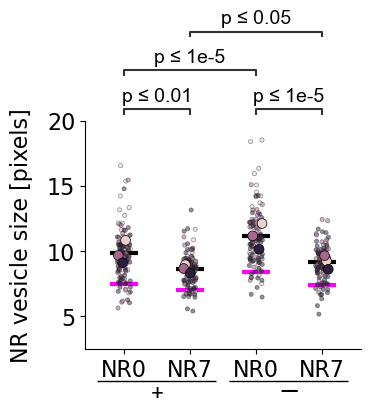

In [30]:
boxplot_font= 16
tick_font =16
text_offset = -0.225
y_pos = -0.14 #0.125 for fractions

ymin= 0
ymax= 0.3

fig, ax = plt.subplots(figsize=(4, 4))

"""sns.boxplot(
    data=df_statistics_per_frame_mean,
    x="group",
    y=col,
    order=order,
    palette=palette,
    showfliers=False,
    width=0.4,
    ax=ax,
    #showmeans=True,  # <--- Blendet den Mittelwert ein!
    #meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6}
)"""

"""
sns.barplot( 
    data= df_biorep_gmean,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    palette = palette_barplt,
    legend = False,
    errorbar="se", 
    width = 0.4,
    capsize = 0.1,
    fill = True
)
"""


df_biorep_gmean = pd.read_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Statistics\df_statistics_gmean_biorep.csv")


#Arithmetric mean

sns.pointplot(x='group', 
              y=col, 
            data=df_statistics_per_biorep_mean, 
            estimator="mean",       # Calculate the mean
            errorbar=None,          # Remove error bars
            markers="_",            # Use horizontal line marker
            markersize=20,          # Make the line wider
            markeredgewidth=3,      # Make the line thicker
            color="black",            # Color of the line
            linestyle="none",
             ax = ax,
             order = order)


# Geometric Mean single bar
sns.pointplot(x='group', 
              y=col, 
            data=df_biorep_gmean, 
            estimator="mean",       # Calculate the mean
            errorbar=None,          # Remove error bars
            markers="_",            # Use horizontal line marker
            markersize=20,          # Make the line wider
            markeredgewidth=3,      # Make the line thicker
            color="magenta",            # Color of the line
            linestyle="none",
             ax = ax,
             order = order)
            

sns.stripplot( 
    data= df_statistics_per_frame_mean,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    hue = "biorep",
    #palette = palette_dts,
    s=3,
    legend = False,
    #edgecolor="black", #Black border around squares
    linewidth=0.5,
    alpha=0.5, #0.6
    clip_on = False
)



#Biorep Data points
sns.stripplot( 
    data=  df_statistics_per_biorep_mean,
    x= "group",
    y= col, 
    order = order,
    ax= ax,
    hue = "biorep",
    #palette = palette_dts,
    s=7, #7
    legend = False,
    edgecolor="black", #Black border around squares
    linewidth=0.5,
    alpha=1, #0.8
    #color = "black",
    clip_on = False
) 

sns.despine(ax=ax, top=True, right=True, trim=False)  # ← trim=False


# -------------------------------
# GROUP LABELS PRO SUBPLOT
# -------------------------------
xticks = ax.get_xticks()

# Mitte der ersten 2 und letzten 2 Boxen
x_1nM = (xticks[0] + xticks[1]) / 2
x_10nM = (xticks[2] + xticks[3]) / 2

ax.text(
    x_1nM, text_offset,
    "+",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize= boxplot_font,
    color = "black"
)

ax.text(
    x_10nM, - 0.16,
    "_",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize= 20,
    color = "black"
)


y = y_pos  # unter der Achse (in axes coords)

# 1 nM (linke 2 Boxen)
ax.hlines(
    y=y, xmin=-0.4, xmax=1.4,
    transform=ax.get_xaxis_transform(),
    color="black",
    linewidth=1,
    clip_on=False
)

# 10 nM (rechte 2 Boxen)
ax.hlines(
    y=y, xmin=1.6, xmax=3.4,
    transform=ax.get_xaxis_transform(),
    color="black",
    linewidth=1,
    clip_on=False
)


ax.set_title(None)
ax.set_xlabel("")
ax.tick_params(axis='both', labelsize= tick_font)
ax.set_ylabel(ylabel[col], fontsize = boxplot_font, labelpad = 10)
#ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(["NR0","NR7","NR0","NR7"], fontsize = tick_font)
ax.spines['top'].set_color("lightgray")
ax.spines['right'].set_color("lightgray")
#ax.set_box_aspect(1)
#ax.set_anchor('E')
#ax.margins(y=0.01)
yticks = ax.get_yticks()
ax.set_ylim(ymin, ymax)
ax.set_ylim(yticks[0], yticks[-1])
#ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))

#ax.set_yticks([0, 500, 1000, 1500, 2000, 2500])

#-------------------------------
# P-VALUES
#----------------------------------
# Initialize the annotator
annot = Annotator(ax, pairs, data=df_statistics_per_frame_mean, x="group", y= col, order = order)
annot.configure(text_format='simple', loc='outside', fontsize = 14, text_offset=3)


(annot
 .set_pvalues(pvalues=p_values_one_metric)
 .annotate())




for text in ax.texts:
    text.set_fontname("Arial")


plt.subplots_adjust(
    left=0.3,
    right=0.99,
    top=0.72,
    bottom=0.15)




plt.savefig(f"D:/Uni/Master/Masterarbeit/Image Analysis/Figures/Subfigures/Stripplot_{col}_boxfont_{boxplot_font}_tick_font{tick_font}_exp_4-6_no_erosion_min_ves_3_p_values_gmean_suppl_dist", dpi=600, transparent = True)
plt.show()

In [933]:
print(df_statistics_per_frame_mean.columns.tolist())

['biorep', 'Techn_repl', 'group', 'cycle', 'frame', 'NR_vesicle_count', 'NR_vesicle_int', 'NR_mean_cell_signal', 'NR_vesicle_fraction', 'overlap_endo_int_frac', 'fraction_nr_in_endo', 'fraction_endo_with_nr', 'overlap_lyso_int_frac', 'fraction_nr_in_lyso', 'fraction_lyso_with_nr', 'nr_size', 'mean_ves_int']


In [936]:
metrics = ['NR_vesicle_count' 'NR_total_vesicle_intensity_median'
 'NR_mean_signal_per_cell' 'NR_fraction_of_segmented_pixels'
 'Overlap_endo_intensity_frac' 'fraction_nr_in_endo'
 'fraction_endo_with_nr' 'Overlap_lyso_intensity_frac'
 'fraction_nr_in_lyso' 'fraction_lyso_with_nr']

for metric in metrics:
    
    plt.figure(figsize=(8,8))
    
    sns.boxplot(
        data=df_statistics_per_frame_mean,
        x="group",
        y=metric,
        showfliers = False
    )
    
    sns.stripplot(
        data=df_statistics_per_frame_mean,
        x="group",
        y=metric,
        hue="biorep",
        dodge=False
    )
    
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

ValueError: Could not interpret value `NR_vesicle_countNR_total_vesicle_intensity_medianNR_mean_signal_per_cellNR_fraction_of_segmented_pixelsOverlap_endo_intensity_fracfraction_nr_in_endofraction_endo_with_nrOverlap_lyso_intensity_fracfraction_nr_in_lysofraction_lyso_with_nr` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x800 with 0 Axes>

In [934]:
import matplotlib.pyplot as plt

metric = "fraction_nr_in_endo"

data = df_statistics_per_biorep


for c1, c2 in comparisons:
    
    plt.figure(figsize=(4,5))
    
    for bio in data["biorep"].unique():
        
        vals = data[
            data["biorep"] == bio
        ]
        
        y1 = vals[vals["group"] == c1][metric].values[0]
        y2 = vals[vals["group"] == c2][metric].values[0]
        
        plt.plot(
            [0,1],
            [y1,y2],
            marker="o"
        )
    
    plt.xticks(
        [0,1],
        [c1,c2],
        rotation=45
    )
    
    plt.title(metric)
    plt.tight_layout()
    plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 400x500 with 0 Axes>

In [937]:
cell_counts = {
    ("NR7_minus"): NR7_minus_len,
    ("NR7_plus"): NR7_plus_len,
    ("NR0_minus"): NR0_minus_len,
    ("NR0_plus"): NR0_plus_len
}

palette = {
    "NR0_minus": "#3B0F70",
    "NR0_plus": "#8C2981",
    "NR7_minus": "#FE9F6D",
    "NR7_plus": "#DE4968",
}


overlap_df_endo_all = pd.concat(overlap_df_endo, ignore_index = True)
df_plot = overlap_df_endo_all[
    overlap_df_endo_all["group"] != "ctrl minus"
]

df_plot = df_plot.copy()
df_plot["n_cells"] = (
    df_plot["group"].map(cell_counts)
)

df_plot = df_plot.copy()
df_plot["kde_weight"] = (
    1 / df_plot["n_cells"]
)

order = ["NR0_minus", "NR0_plus", "NR7_plus", "NR7_minus"]
fig, axes = plt.subplots(figsize = (5,4))

sns.kdeplot(
    data = df_plot,
    x = "overlap_frac_of_nr_in_endo",
    hue = "group",
    fill = True,
    alpha = 0.7,
    linewidth = 0.1,
    palette = palette,
    weights="kde_weight",
    common_norm = True,
    hue_order = order,
    clip=(0, 1)
    )

sns.despine(ax=axes, top=True, right=True)

axes.set_xlabel("Fraction of endosome vesicle overlapping with NRs")
axes.xaxis.set_major_locator(MultipleLocator(0.2))
axes.xaxis.set_minor_locator(MultipleLocator(0.1))
axes.set_ylim(0,1)
axes.set_xlim(-0.1,1.2)


axes.legend([ "NR0 –", "NR0 +", "NR7 +", "NR7 –"], title= "Condition")

#plt.savefig(r"D:\Uni\Master\Masterarbeit\Image Analysis\Figures\Subfigures\Density_plot_NR_in_Endo.png", dpi = 600)

NameError: name 'NR7_minus_len' is not defined

## Boxplot NR uptake Figure

In [ ]:
def statistic_NR(df):
    return [
        df["NR mean signal per cell"].median(),
        df["NR fraction of segmented pixels"].median(),
        df["NR total vesicle intensity median"].median(),
        df["NR vesicle count"].median()
                ]
index= ["NR mean signal per cell",
        "NR fraction of segmented pixels",
        "NR total vesicle intensity", 
        "NR vesicle count"]

def sample_stats(NR0_1nM, NR0_10nM, NR7_1nM, NR7_10nM, ctrl):
    stats= pd.DataFrame({
        "NR0 1nM": statistic(NR0_1nM),
        "NR7 1nM": statistic(NR7_1nM),
        "NR0 10nM": statistic(NR0_10nM),
        "NR7 10nM": statistic(NR7_10nM)}, index=index)
    return stats

In [ ]:
order= ["NR0 1nM", "NR7 1nM", "NR0 10nM", "NR7 10nM"]

index= ["NR mean signal per cell",
        "NR fraction of segmented pixels",
        "NR total vesicle intensity", 
        "NR vesicle count"]
ylabels = {
    "NR mean signal per cell": "Mean NR intensity per cell",
    "NR fraction of segmented pixels": "NR vesicle farction",
    "NR vesicle count": "NR vesicle count",
    "NR total vesicle intensity median": "NR intensity per vesicle"
}


columns = ["NR mean signal per cell",
           "NR fraction of segmented pixels",
           "NR vesicle count",
           "NR total vesicle intensity median"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, index in zip(axes.flatten(), columns, index):
    sns.boxplot(
        data=df_long,
        y=col,
        x="group",
        order=order,
        palette={
        "NR0 1nM": "#FC76AB",
        "NR7 1nM": "#B0043F",
        "NR0 10nM": "#FC76AB",
        "NR7 10nM": "#B0043F"
    },
        showfliers=False,
        ax=ax,
        width=0.3
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabels[col])
    ax.set_title(index)
    ax.tick_params(axis='x', rotation=45)  # Beschriftung schräg wenn zu lang
    if col in ylims:
        ax.set_ylim(ylims[col])


fig.suptitle(f" cells with >= {min_vesicle} vesicles")
plt.tight_layout()
#plt.savefig(f"D:/Uni\Master/Masterarbeit/Image Analysis/Exp.2.3 Plots and Tables/thresh_80_min_vesicles{min_vesicle}.png", dpi=600, bbox_inches='tight')
plt.show()

## Overview table

In [ ]:
def statistic_short(df_raw, df):
    return [
        len(df_raw),
        len(df),
        (len(df)/len(df_raw))*100]
           
index= ["Cell count",
        "Cells with >0 NR vesicles",
        "Inculded into analysis [%]"]
        
def sample_stats_short(NR0_1nM_raw, NR0_1nM, 
                       NR0_10nM_raw, NR0_10nM,
                       NR7_1nM_raw, NR7_1nM,
                       NR7_10nM_raw, NR7_10nM):
    stats= pd.DataFrame({
        "NR0 1nM": statistic_short(NR0_1nM_raw, NR0_1nM),
        "NR7 1nM": statistic_short(NR7_1nM_raw, NR7_1nM),
        "NR0 10nM": statistic_short(NR0_10nM_raw, NR0_10nM),
        "NR7 10nM": statistic_short(NR7_10nM_raw, NR7_10nM)}, index=index)
    return stats

In [ ]:
statistic_df_short= sample_stats_short(NR0_1nM_raw, NR0_1nM, 
                                       NR0_10nM_raw, NR0_10nM,
                                       NR7_1nM_raw, NR7_1nM,
                                       NR7_10nM_raw, NR7_10nM)
statistic_df_short.index = index
statistic_df_short = statistic_df_short.round(3)
#statistic_df_short.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Images for figures\Subfigures\NR_uptake_overview.csv")

In [ ]:
display(statistic_df_short)

## Boxplots all

In [ ]:
print(df_long.columns.tolist())

In [ ]:
def statistic(df):
    return [
        len(df),
        df["Endo NR intersection nr segm"].median(),
        df["Endo NR fraction per nr segm"].median(),
        df["Lyso NR intersection nr segm"].median(),
        df["Lyso NR fraction per nr segm"].median(),
        df["NR intensity overlap endo"].median(),
        df["Overlap endo intensity frac"].median(),
        df["NR intensity overlap lyso"].median(),
        df["Overlap lyso intensity frac"].median(),
        df["Endo total area"].median(),
        df["Lyso total area"].median(),
        df["Endo vesicle count"].median(),
        df["Lyso vesicle count"].median(),
        df["NR mean signal per cell"].median()
                ]
index= ["No. cells",
        "Endo intersection",
        "Endo fraction", 
        "Lyso intersection",
        "Lyso fraction",  
        "Endo intensity intersection",
        "Endo intensity fraction",
        "Lyso intensity intersection",
        "Lyso intensity fraction",
        "Endo area",
        "Lyso area",
        "Endo count",
        "Lyso count",
        "NR mean signal/cell"]

def sample_stats(NR0_1nM, NR0_10nM, NR7_1nM, NR7_10nM, ctrl):
    stats= pd.DataFrame({
        "NR0 1nM": statistic(NR0_1nM),
        "NR7 1nM": statistic(NR7_1nM),
        "NR0 10nM": statistic(NR0_10nM),
        "NR7 10nM": statistic(NR7_10nM)}, index=index)
    return stats

In [ ]:
order= ["NR0 1nM", "NR7 1nM", "NR0 10nM", "NR7 10nM"]
index=["NR mean signal per cell", 
       "NR total vesicle intensity", 
       "NR vesicle count", 
       "Overlap with Lyso", 
       "Fraction of NR in Lyso", 
       "Overlap with Endo",
       "Fraction of NR in Endo",
       "Fraction of NR vesicles in Lyso",
       "Fraction of NR vesicles in Endo"
      ]

ylims = {
    "NR intensity overlap lyso": (-5000, 110000),
    "Overlap lyso intensity frac": (-0.05, 1),
    "NR intensity overlap endo": (-5000, 110000),
    "Overlap endo intensity frac": (-0.05, 1),
    "Lyso NR fraction per nr segm": (-0.05, 1),
    "Endo NR fraction per nr segm": (-0.05, 1)
}

ylabels = {
    "NR mean signal per cell": "NR signal",
    "NR total vesicle intensity median": "NR vesicle intensity",
    "NR vesicle count": "count",
    "NR intensity overlap lyso": "NR intensity",
    "Overlap lyso intensity frac": "NR intensity [frac]",
    "NR intensity overlap endo": "NR intensity",
    "Overlap endo intensity frac": "NR intensity [frac]",
    "Lyso NR fraction per nr segm": "NR pixels [frac]",
    "Endo NR fraction per nr segm": "NR pixels [frac]"
}


columns = [
    "NR mean signal per cell",
    "NR total vesicle intensity median",
    "NR vesicle count",
    "NR intensity overlap lyso",
    "Overlap lyso intensity frac",
    "NR intensity overlap endo",
    "Overlap endo intensity frac",
    "Lyso NR fraction per nr segm",
    "Endo NR fraction per nr segm"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for ax, col, index in zip(axes.flatten(), columns, index):
    sns.boxplot(
        data=df_long,
        y=col,
        x="group",
        order=order,
        palette={
        "NR0 1nM": "#FC76AB",
        "NR7 1nM": "#B0043F",
        "NR0 10nM": "#FC76AB",
        "NR7 10nM": "#B0043F"
    },
        showfliers=False,
        ax=ax,
        width=0.5
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabels[col])
    ax.set_title(index)
    ax.tick_params(axis='x', rotation=45)  # Beschriftung schräg wenn zu lang
    if col in ylims:
        ax.set_ylim(ylims[col])


fig.suptitle(f" cells with >= {min_vesicle} vesicles")
plt.tight_layout()
#plt.savefig(f"D:/Uni\Master/Masterarbeit/Image Analysis/Exp.2.3 Plots and Tables/thresh_80_min_vesicles{min_vesicle}.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_overlaps_endo = []

for _, row in df_long.iterrows():
    overlaps = json.loads(row["List for coloc per vesicle endo"])

    for overlap in overlaps:
        overlap["Cell ID"] = row["Cell ID"]
        overlap["frame"] = row["frame"]
        overlap["cycle"] = row["cycle"]
        overlap["sample"] =row["group"]
        overlap["cell_uid"] =row["cell_uid"]

        all_overlaps_endo.append(overlap)

overlap_df_endo = pd.DataFrame(all_overlaps_endo)

In [ ]:
all_overlaps_lyso = []

for _, row in df_long.iterrows():
    overlaps = json.loads(row["List for coloc per vesicle lyso"])

    for overlap in overlaps:
        overlap["Cell ID"] = row["Cell ID"]
        overlap["frame"] = row["frame"]
        overlap["cycle"] = row["cycle"]
        overlap["sample"] =row["group"]
        overlap["cell_uid"] =row["cell_uid"]

        all_overlaps_lyso.append(overlap)

overlap_df_lyso = pd.DataFrame(all_overlaps_lyso)

In [ ]:
min_overlap=0.5
overlap_endo_filtered= overlap_df_endo [overlap_df_endo["overlap_frac_of_nr_in_endo"] > min_overlap]
overlap_lyso_filtered= overlap_df_lyso [overlap_df_lyso["overlap_frac_of_nr_in_lyso"] > min_overlap]

In [ ]:
positive_per_cell_endo = (
    overlap_endo_filtered
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_nr_vesicles_endo")
)
positive_per_cell_lyso = (
    overlap_lyso_filtered
    .groupby(["cell_uid"])
    .size()
    .reset_index(name="positive_nr_vesicles_lyso")
)

In [ ]:
df_long_mod = df_long.merge(
    positive_per_cell_endo,
    on="cell_uid",
    how="left"
)

df_long_mod = df_long_mod.merge(
    positive_per_cell_lyso,
    on="cell_uid",
    how="left"
)

df_long_mod["positive_nr_vesicles_endo"] = (
    df_long_mod["positive_nr_vesicles_endo"]
    .fillna(0)
    .astype(int)
)
df_long_mod["positive_nr_vesicles_lyso"] = (
    df_long_mod["positive_nr_vesicles_lyso"]
    .fillna(0)
    .astype(int)
)

df_long_mod = df_long_mod.drop("List for coloc per vesicle endo", axis=1)
df_long_mod = df_long_mod.drop("List for coloc per vesicle lyso", axis=1)

In [ ]:
df_long_mod["fraction_nr_in_endo"] = (
    df_long_mod["positive_nr_vesicles_endo"] / df_long_mod["NR vesicle count"]
)
df_long_mod["fraction_nr_in_lyso"] = (
    df_long_mod["positive_nr_vesicles_lyso"] / df_long_mod["NR vesicle count"]
)

df_long_mod["fraction_endo_with_nr"] = (
    df_long_mod["positive_nr_vesicles_endo"] / df_long_mod["Endo vesicle count"]
)
df_long_mod["fraction_lyso_with_nr"] = (
    df_long_mod["positive_nr_vesicles_lyso"] / df_long_mod["Lyso vesicle count"]
)
display(df_long_mod)
df_long_mod.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Excel Files Complete Analysis\Data complete without erosion and min_vesicles 3\Full_df_no_erosion_min_ves_3.csv")


In [ ]:
order= ["NR0 1nM", "NR7 1nM", "NR0 10nM", "NR7 10nM"]
index=["positive_nr_vesicles_endo",
       "positive_nr_vesicles_lyso",
       "fraction_nr_in_endo",
       "fraction_nr_in_lyso",
       #"fraction_endo_with_nr",
       #"fraction_lyso_with_nr"       
      ]

ylims = {
    "positive_nr_vesicles_endo": (-0.5, 10),
    "positive_nr_vesicles_lyso":(-0.5, 10),
    "fraction_nr_in_endo":(-0.1,1),
    "fraction_nr_in_lyso": (-0.1,1),
    #"fraction_endo_with_nr":(-0.1,1),
    #"fraction_lyso_with_nr": (-0.1,1)
}

ylabels = {
    "positive_nr_vesicles_endo": "vesicle count",
    "positive_nr_vesicles_lyso": "vesicle count",
    "fraction_nr_in_endo": "vesicel count [frac]",
    "fraction_nr_in_lyso": "vesicel count [frac]",
    #"fraction_endo_with_nr": "vesicel count [frac]",
    #"fraction_lyso_with_nr": "vesicel count [frac]"
}


columns = [
    "positive_nr_vesicles_endo",
    "positive_nr_vesicles_lyso",
    "fraction_nr_in_endo",
    "fraction_nr_in_lyso",
    #"fraction_endo_with_nr",
    #"fraction_lyso_with_nr"
]

fig, axes = plt.subplots(4, 1, figsize=(3, 12))

for ax, col, index in zip(axes.flatten(), columns, index):
    sns.boxplot(
        data=df_long_mod,
        y=col,
        x="group",
        order=order,
        palette={
        "NR0 1nM": "#FC76AB",
        "NR7 1nM": "#B0043F",
        "NR0 10nM": "#FC76AB",
        "NR7 10nM": "#B0043F"
    },
        showfliers=False,
        ax=ax,
        width=0.5
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabels[col])
    ax.set_title(index)
    ax.tick_params(axis='x', rotation=45)  # Beschriftung schräg wenn zu lang
    if col in ylims:
        ax.set_ylim(ylims[col])


fig.suptitle(f" cells with > {min_overlap} overlap")
plt.tight_layout()
#plt.savefig(f"D:/Uni\Master/Masterarbeit/Image Analysis/Exp.2.3 Plots and Tables/thresh_80_min_vesicles{min_vesicle}.png", dpi=300, bbox_inches='tight')
#plt.savefig(r"D:\Uni\Master\Masterarbeit\Image Analysis\Images for figures\Subfigures\test")
plt.show()